In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.8 MB/s eta 0:00:00


In [5]:
# INSTALACIÓN DE EASYOCR
!pip install easyocr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 27.0 MB/s eta 0:00:00


In [6]:

# IMPORTAR LIBRERÍAS
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from google.colab import drive
import shutil
import random
from sklearn.model_selection import train_test_split
import xml.etree.ElementTree as ET
from ultralytics import YOLO
from google.colab import files
import easyocr

In [3]:
#DESCARGAR DATASET
path = kagglehub.dataset_download("andrewmvd/car-plate-detection")  #el data set se obtiene desde kaggle

print("Dataset descargado:")                                        #ruta donde se descarga el dataset
print(path)

100%|██████████| 203M/203M [00:02<00:00, 99.9MB/s]

Extracting files...


Dataset descargado:
/root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1


#Creacion de la estructura del dataset en carpetas

In [4]:
#CREACION DE ESTRUCTURA YOLO
#divide el datset en dos carpetas: validacion y entrenamiento tando de etiquetas como de imagenes
base_output = "dataset"

train_img_dir = os.path.join(base_output, "images/train") #ruta par para imagenes de entrenamiento
val_img_dir = os.path.join(base_output, "images/val")     #ruta par para imagenes de validación

train_lbl_dir = os.path.join(base_output, "labels/train") #ruta para las imagenes etiquetadas como entrenamiento
val_lbl_dir = os.path.join(base_output, "labels/val")  #ruta para las imagenes etiquetadas como validación
# exist_ok=True evita errores si las carpetas ya existen
os.makedirs(train_img_dir, exist_ok=True)
os.makedirs(val_img_dir, exist_ok=True)

os.makedirs(train_lbl_dir, exist_ok=True)
os.makedirs(val_lbl_dir, exist_ok=True)

print("Estructura YOLO creada.")                          #mensaje afirmatorio sobre la ejecución

Estructura YOLO creada.


#Obtencion de imagenes de la pagina y procesamiento de imagenes

In [5]:
images_dir = os.path.join(path, "images")
annotations_dir = os.path.join(path, "annotations")

# Obtener imágenes
imagenes = [
    f for f in os.listdir(images_dir)
    if f.endswith((".jpg", ".jpeg", ".png"))
]

# División 80/20
train_imgs, val_imgs = train_test_split(
    imagenes,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# FUNCIÓN DE PREPROCESAMIENTO POR IMAGEN
def preprocesar_imagen(ruta_imagen):
    """
    Aplica preprocesamiento a una imagen:
    - Conversión BGR -> RGB
    - Reducción de ruido (GaussianBlur)
    - Mejora de contraste (CLAHE en espacio LAB)
    - Normalización a [0,1]
    Devuelve la imagen procesada en uint8 (0-255) lista para guardar.
    """
    image = cv2.imread(ruta_imagen)

    if image is None:
        print(f"No se pudo leer la imagen: {ruta_imagen}")
        return None

    # Conversión de sistema de color a RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Filtro para reducir el ruido
    denoised = cv2.GaussianBlur(image_rgb, (3, 3), 0)

    # Conversión de la imagen a formato LAB y separación de los canales de color
    lab = cv2.cvtColor(denoised, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # Mejora de contraste con CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    enhanced = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

    # Normaliza los valores de la imagen entre 0 y 1
    normalized = enhanced / 255.0

    # Reescala a 0-255 en uint8 para poder guardarla como imagen estándar
    processed_uint8 = (normalized * 255).astype(np.uint8)

    return processed_uint8

#Division del dataset con su respectiva etiqueta

In [6]:
#Dividir dataset

def copiar_con_etiquetas(lista_imgs, destino_img, destino_lbl):

    for img in lista_imgs:

        ruta_origen = os.path.join(images_dir, img)

        # Preprocesar la imagen
        imagen_procesada = preprocesar_imagen(ruta_origen)

        if imagen_procesada is None:
            continue  # si no se pudo leer, se salta esta imagen

        ruta_destino_img = os.path.join(destino_img, img)

        # La imagen procesada está en RGB, hay que volver a BGR para guardar con cv2
        imagen_para_guardar = cv2.cvtColor(imagen_procesada, cv2.COLOR_RGB2BGR)
        cv2.imwrite(ruta_destino_img, imagen_para_guardar)

        # Nombre base
        nombre = os.path.splitext(img)[0]

        xml = nombre + ".xml"

        ruta_xml = os.path.join(annotations_dir, xml)

        if os.path.exists(ruta_xml):
            shutil.copy(
                ruta_xml,
                os.path.join(destino_lbl, xml)
            )
        else:
            print(f"No se encontró: {xml}")


# Entrenamiento
copiar_con_etiquetas(
    train_imgs,
    train_img_dir,
    train_lbl_dir
)

# Validación
copiar_con_etiquetas(
    val_imgs,
    val_img_dir,
    val_lbl_dir
)

print("Dataset dividido y preprocesado correctamente.")

Dataset dividido y preprocesado correctamente.


In [7]:
def convertir_xml_a_yolo(ruta_xml, ruta_txt_salida, clases):
    """
    Lee un archivo XML en formato Pascal VOC y escribe un .txt
    en formato YOLO: clase x_center y_center width height (normalizado 0-1)
    """
    tree = ET.parse(ruta_xml)
    root = tree.getroot()

    # Tamaño de la imagen original
    size = root.find("size")
    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    lineas_yolo = []

    for obj in root.findall("object"):
        nombre_clase = obj.find("name").text

        # Si la clase no existe en el diccionario, se agrega
        if nombre_clase not in clases:
            clases[nombre_clase] = len(clases)

        clase_id = clases[nombre_clase]

        bndbox = obj.find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        # Conversión a formato YOLO (normalizado)
        x_center = ((xmin + xmax) / 2) / img_w
        y_center = ((ymin + ymax) / 2) / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        lineas_yolo.append(f"{clase_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    with open(ruta_txt_salida, "w") as f:
        f.write("\n".join(lineas_yolo))


def convertir_carpeta_xml_a_yolo(carpeta_labels, clases):
    """
    Recorre todos los .xml de una carpeta, los convierte a .txt
    y elimina el .xml original.
    """
    xmls = glob.glob(os.path.join(carpeta_labels, "*.xml"))

    for ruta_xml in xmls:
        nombre = os.path.splitext(os.path.basename(ruta_xml))[0]
        ruta_txt = os.path.join(carpeta_labels, nombre + ".txt")

        convertir_xml_a_yolo(ruta_xml, ruta_txt, clases)

        # Eliminar el XML ya convertido (opcional)
        os.remove(ruta_xml)

    print(f"{len(xmls)} archivos convertidos en: {carpeta_labels}")


# Diccionario de clases compartido entre train y val
clases = {}

convertir_carpeta_xml_a_yolo(train_lbl_dir, clases)
convertir_carpeta_xml_a_yolo(val_lbl_dir, clases)

print("Clases detectadas:", clases)

# Guardar el archivo de clases (necesario para el entrenamiento YOLO)
with open(os.path.join(base_output, "classes.txt"), "w") as f:
    for nombre_clase, idx in sorted(clases.items(), key=lambda x: x[1]):
        f.write(nombre_clase + "\n")

print("Archivo classes.txt creado.")

346 archivos convertidos en: dataset/labels/train
87 archivos convertidos en: dataset/labels/val
Clases detectadas: {'licence': 0}
Archivo classes.txt creado.


In [8]:
import yaml

# Ruta absoluta de la carpeta dataset (importante en Colab)
ruta_absoluta = os.path.abspath(base_output)

# Ordenar las clases por su índice para que coincidan con los .txt generados
nombres_clases = [nombre for nombre, idx in sorted(clases.items(), key=lambda x: x[1])]

data_yaml = {
    "path": ruta_absoluta,                      # carpeta raíz del dataset
    "train": "images/train",                    # relativo a "path"
    "val": "images/val",                         # relativo a "path"
    "nc": len(nombres_clases),                   # número de clases
    "names": nombres_clases                      # lista de nombres de clases
}

ruta_yaml = os.path.join(base_output, "data.yaml")

with open(ruta_yaml, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print("data.yaml creado en:", ruta_yaml)
print()
with open(ruta_yaml, "r") as f:
    print(f.read())

data.yaml creado en: dataset/data.yaml

path: /content/dataset
train: images/train
val: images/val
nc: 1
names:
- licence



In [9]:
model = YOLO("yolov8n.pt")  # o el modelo base que prefieras
model.train(data="dataset/data.yaml", epochs=50, imgsz=640)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bc62ade1d00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [10]:
# Ruta de la carpeta de resultados del entrenamiento
# Ajusta el nombre si ya existe más de un "train" (train2, train3, etc.)
ruta_resultados = "runs/detect/train"

# Comprimir toda la carpeta de resultados en un .zip
shutil.make_archive("resultados_yolo", "zip", ruta_resultados)

# Descargar el zip directamente a tu computadora
files.download("resultados_yolo.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# Cargar el modelo ya entrenado (pesos guardados durante el entrenamiento)
model = YOLO("best.pt")

# Hacer una predicción sobre una sola imagen
resultados = model.predict(
    source="/content/placas/placa.jpg",
    conf=0.25,      # umbral de confianza mínimo para mostrar una detección
    save=True       # guarda la imagen con las cajas dibujadas en runs/detect/predict
)

# Mostrar resultados en consola (clase, confianza, coordenadas de la caja)
for r in resultados:
    print(r.boxes)


image 1/1 /content/placas/placa.jpg: 384x640 (no detections), 642.4ms
Speed: 24.3ms preprocess, 642.4ms inference, 15.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([])
conf: tensor([])
data: tensor([], size=(0, 6))
id: None
is_track: False
orig_shape: (226, 400)
shape: torch.Size([0, 6])
xywh: tensor([], size=(0, 4))
xywhn: tensor([], size=(0, 4))
xyxy: tensor([], size=(0, 4))
xyxyn: tensor([], size=(0, 4))


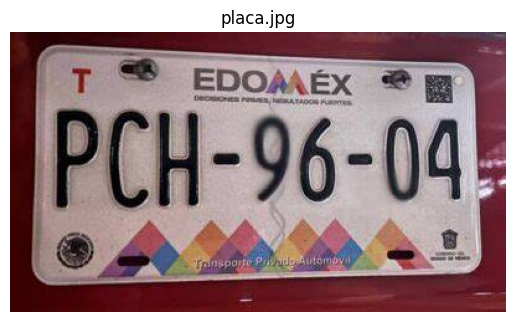

No se detectó placa en: placa.jpg


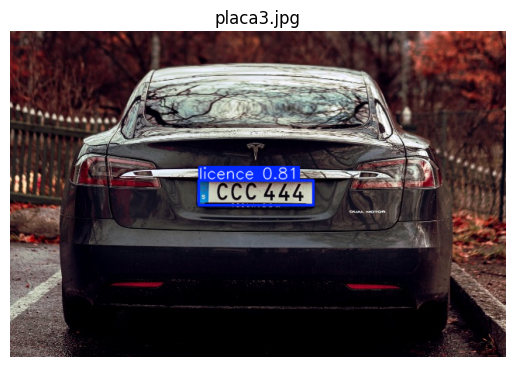

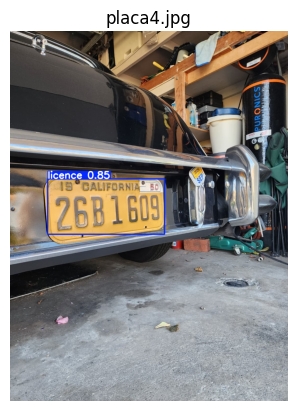

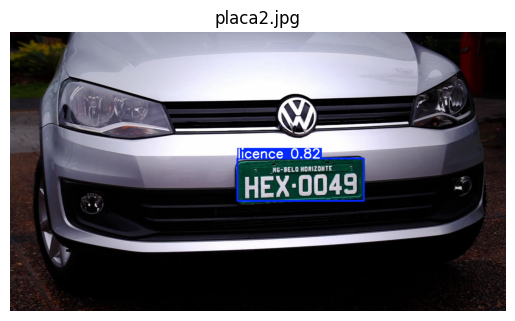

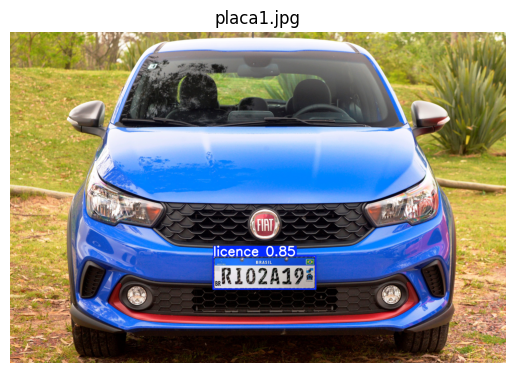

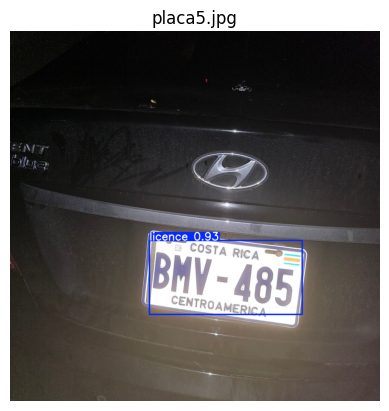

Proceso terminado. Recortes guardados en: placas_recortadas


In [4]:
# Carpeta con las imágenes a procesar
carpeta_entrada = "/content/placas"

# Carpeta nueva donde se guardarán solo los recortes de las placas
carpeta_recortes = "placas_recortadas"
os.makedirs(carpeta_recortes, exist_ok=True)

# Extensiones de imagen válidas
extensiones_validas = (".jpg", ".jpeg", ".png")

imagenes = [
    f for f in os.listdir(carpeta_entrada)
    if f.lower().endswith(extensiones_validas)
]

for nombre_img in imagenes:

    ruta_img = os.path.join(carpeta_entrada, nombre_img)

    # Leer imagen original (sin preprocesamiento)
    imagen = cv2.imread(ruta_img)

    if imagen is None:
        print(f"No se pudo leer: {nombre_img}")
        continue

    # Correr detección
    resultados = model.predict(source=ruta_img, conf=0.25, verbose=False)

    nombre_base = os.path.splitext(nombre_img)[0]

    for r in resultados:

        # Mostrar la imagen con las cajas dibujadas (placa detectada)
        imagen_anotada = r.plot()
        imagen_anotada_rgb = cv2.cvtColor(imagen_anotada, cv2.COLOR_BGR2RGB)
        plt.imshow(imagen_anotada_rgb)
        plt.axis("off")
        plt.title(nombre_img)
        plt.show()

        cajas = r.boxes

        if len(cajas) == 0:
            print(f"No se detectó placa en: {nombre_img}")
            continue

        # Si hay varias detecciones en la misma imagen, se numeran
        for i, caja in enumerate(cajas):
            x1, y1, x2, y2 = map(int, caja.xyxy[0])

            recorte = imagen[y1:y2, x1:x2]

            if cajas.shape[0] > 1:
                nombre_salida = f"{nombre_base}_placa{i+1}.jpg"
            else:
                nombre_salida = f"{nombre_base}_placa.jpg"

            ruta_salida = os.path.join(carpeta_recortes, nombre_salida)
            cv2.imwrite(ruta_salida, recorte)

print("Proceso terminado. Recortes guardados en:", carpeta_recortes)

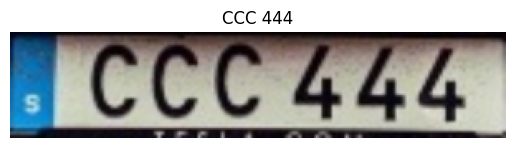

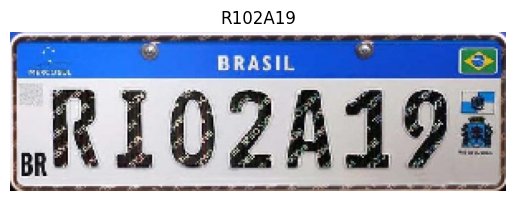

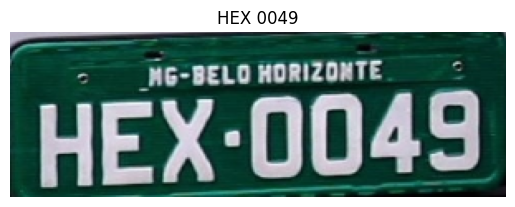

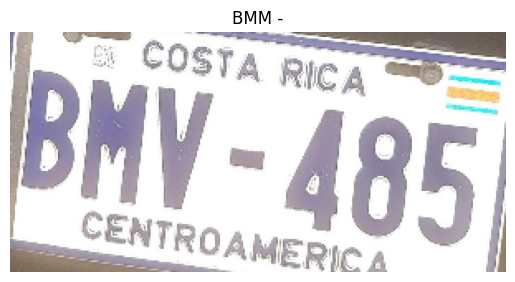

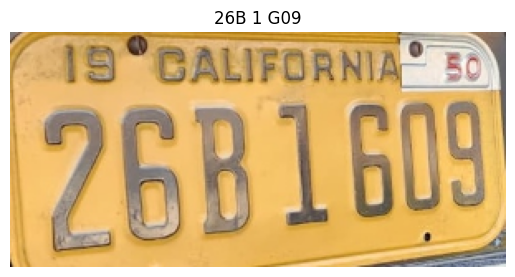

Proceso de OCR terminado.


In [9]:
reader = easyocr.Reader(['en'], gpu=True)

carpeta_recortes = "placas_recortadas"
extensiones_validas = (".jpg", ".jpeg", ".png")

imagenes_placa = [
    f for f in os.listdir(carpeta_recortes)
    if f.lower().endswith(extensiones_validas)
]

def area_bbox(bbox):
    """Calcula el área del cuadrilátero que devuelve EasyOCR"""
    bbox = np.array(bbox)
    x = bbox[:, 0]
    y = bbox[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

for idx, nombre_img in enumerate(imagenes_placa):

    ruta_img = os.path.join(carpeta_recortes, nombre_img)
    plate = cv2.imread(ruta_img)

    if plate is None or plate.size == 0:
        print(f"[{idx+1}] Recorte vacío o ilegible, se omite: {nombre_img}")
        continue

    # ── Resize de la placa ───────────────────────────────
    target_w = 300
    ratio = target_w / plate.shape[1]
    target_h = int(plate.shape[0] * ratio)
    plate = cv2.resize(plate, (target_w, target_h))

    # ── Preprocesamiento ─────────────────────────────────
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    gray_plate = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)
    gray_plate = cv2.bilateralFilter(gray_plate, 7, 75, 75)
    equalized = clahe.apply(gray_plate)

    # ── OCR con EasyOCR ──────────────────────────────────
    resultado_ocr = reader.readtext(equalized)

    if len(resultado_ocr) == 0:
        texto_placa = "No se detectó texto"
    else:
        # Quedarse solo con el bloque de texto con el bbox más grande
        # (el número de placa casi siempre tiene las letras más grandes)
        bloque_principal = max(resultado_ocr, key=lambda r: area_bbox(r[0]))
        texto_placa = bloque_principal[1].strip()

    # ── Mostrar el recorte de la placa junto con el texto detectado ──
    plate_rgb = cv2.cvtColor(plate, cv2.COLOR_BGR2RGB)

    plt.imshow(plate_rgb)
    plt.axis("off")
    plt.title(texto_placa)
    plt.show()

print("Proceso de OCR terminado.")